In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns


In [5]:
data = {
    'SqFt': [1500, 2000, 1200, 2400, 3000, 1800, 1100, 2200, 2700, 1600,
             1400, 1900, 2100, 2500, 1300, 1700, 2300, 2800, 1000, 3100,
            1550, 1950, 2250, 2650, 1350],
    'Age': [10, 5, 20, 2, 1, 15, 30, 8, 4, 12, 18, 7, 6, 3, 25, 11, 5, 2, 40, 1, 9, 6, 4, 3, 22],
    'Rooms': [3, 4, 2, 4, 5, 3, 2, 4, 4, 3, 3, 3, 4, 5, 2, 3, 4, 5, 2, 5, 3, 4, 4, 5, 2],
    'Price': [300, 400, 210, 500, 610, 340, 180, 450, 550, 310, 
              270, 380, 420, 510, 230, 330, 460, 570, 150, 630, 
              315, 395, 455, 540, 245]
}

In [7]:
data = pd.DataFrame(data)
data.head(5)

,SqFt,Age,Rooms,Price
0,1500,10,3,300
1,2000,5,4,400
2,1200,20,2,210
3,2400,2,4,500
4,3000,1,5,610


In [9]:
x = data.iloc[:,:-1]
y = data["Price"]

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled =scaler.fit_transform(x)
X_scaled

array([[-0.79731571, -0.07749359, -0.50756473],
       [ 0.04373462, -0.58731985,  0.46852129],
       [-1.30194591,  0.94215892, -1.48365074],
       [ 0.71657488, -0.8932156 ,  0.46852129],
       [ 1.72583528, -0.99518086,  1.4446073 ],
       [-0.29268551,  0.43233267, -0.50756473],
       [-1.47015598,  1.96181144, -1.48365074],
       [ 0.38015475, -0.28142409,  0.46852129],
       [ 1.22120508, -0.6892851 ,  0.46852129],
       [-0.62910565,  0.12643691, -0.50756473],
       [-0.96552578,  0.73822842, -0.50756473],
       [-0.12447545, -0.38338935, -0.50756473],
       [ 0.21194468, -0.4853546 ,  0.46852129],
       [ 0.88478495, -0.79125035,  1.4446073 ],
       [-1.13373584,  1.45198518, -1.48365074],
       [-0.46089558,  0.02447166, -0.50756473],
       [ 0.54836481, -0.58731985,  0.46852129],
       [ 1.38941514, -0.8932156 ,  1.4446073 ],
       [-1.63836604,  2.98146396, -1.48365074],
       [ 1.89404534, -0.99518086,  1.4446073 ],
       [-0.71321068, -0.17945884, -0.507

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.linear_model import Lasso
# lasso = Lasso(alpha=0.5)
lasso = Lasso(alpha=1.0)                      # thus changing the value of the alpha is resulting in the same accuracy 
lasso.fit(x_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [20]:
lasso.score(x_train,y_train)*100

99.86180252709482

In [22]:
print("Lasso Coefficients:", lasso.coef_)   # as the negative fetures are negavtive means zero and it is not important .

Lasso Coefficients: [114.70192429 -14.93658385   5.41315883]


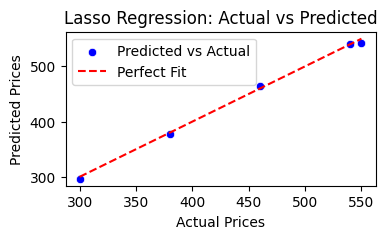

In [23]:
# Make predictions using the trained model
y_pred = lasso.predict(x_test)

plt.figure(figsize=(4, 2))
sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Predicted vs Actual')

# Draw the 45-degree line (Perfect Prediction Line)
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', label='Perfect Fit')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Lasso Regression: Actual vs Predicted')
plt.legend()
plt.show()